In [28]:
import pandas as pd
import numpy as np
import time 
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, confusion_matrix, f1_score, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [29]:
mental_data = 'Teen_Mental_Health_Dataset.csv'

df = pd.read_csv(mental_data)

df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [30]:

print(f"Dataset Size : {df.size} ")
print(f"Reading null data {df.isnull().sum().max()}")

Dataset Size : 15600 
Reading null data 0


<function matplotlib.pyplot.show(close=None, block=None)>

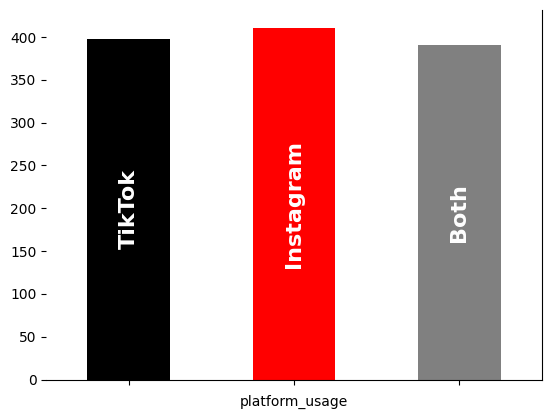

In [31]:
label = ['TikTok', 'Instagram', 'Both']

filtered_label = df['platform_usage'].value_counts().reindex(label).plot.bar(color=['black', 'red', 'gray'])
filtered_label.bar_label(filtered_label.containers[0], labels=label, label_type='center', color='white', rotation=90, fontsize=16, fontweight='bold')

filtered_label.set_xticklabels([])

plt.show

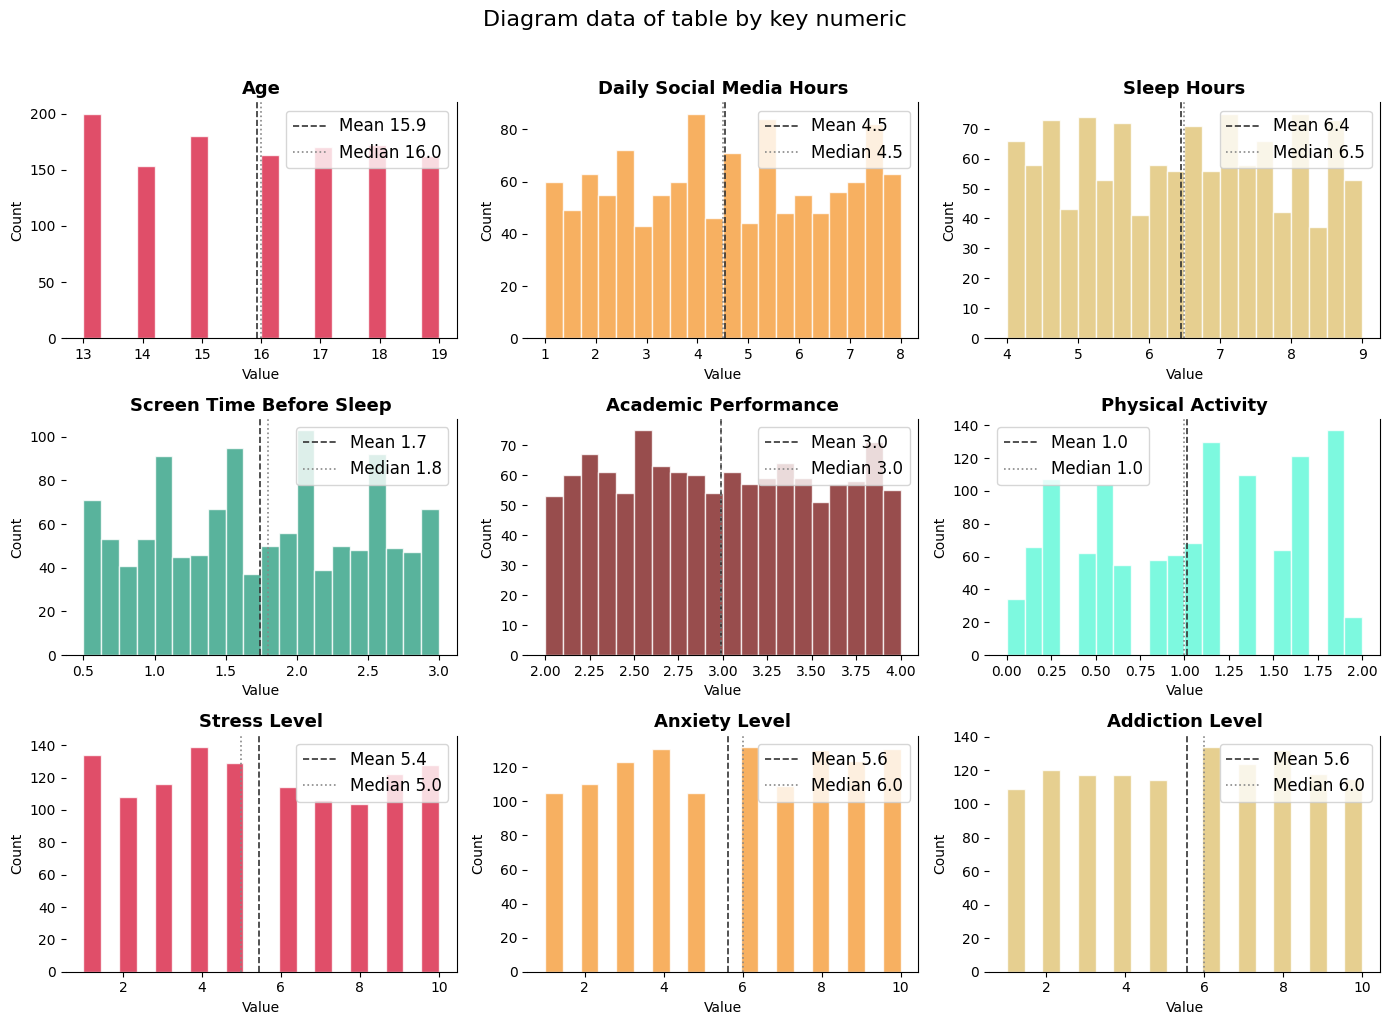

In [34]:
import warnings

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'axes.spines.top': False, 'axes.spines.left': False,
    'axes.titlesize': 13, 'axes.titleweight' : 600
})
num_cols = ["age", "daily_social_media_hours", "sleep_hours", "screen_time_before_sleep", 
            "academic_performance", "physical_activity", "stress_level", "anxiety_level", "addiction_level"]

colors_diagram = ['#D92243', '#F69D39', '#E0C375', '#2FA084', '#7F2020', '#5DF8D8']

fig, axes = plt.subplots(3, 3, figsize=(14,10))

fig.suptitle("Diagram data of table by key numeric", fontsize=16, y=1.02)

for i, filtered_label in enumerate(axes.flatten()):
    col = num_cols[i]
    data = df[col].dropna()
    filtered_label.hist(data, bins=20, color=colors_diagram[i % len(colors_diagram)], edgecolor='white', alpha=0.8)

    filtered_label.axvline(data.mean(), color='#333333', ls='--', lw=1.2, label=f"Mean {data.mean():.1f}")
    filtered_label.axvline(data.median(), color='#888888', ls=':', lw=1.2, label=f"Median {data.median():.1f}")

    filtered_label.set(title=col.replace('_',' ').title(), xlabel='Value', ylabel='Count')
    filtered_label.legend(fontsize=12)

plt.tight_layout()
plt.savefig("chart1_distributions.png", bbox_inches="tight")
plt.show()